In [2]:
import pandas as pd

sr = pd.Series({'a': 1., 'b': 2., 'c': 3.})
print(sr)
print(sr['a'])

a    1.0
b    2.0
c    3.0
dtype: float64
1.0


In [19]:
import math
import yaml
from abc import ABC, ABCMeta, abstractmethod
from dataclasses import dataclass, field
from typing import Callable, Optional, List, Tuple, Dict, Any, get_type_hints, Union
from collections import namedtuple


import math
from dataclasses import dataclass, field
from typing import Callable, Optional, List, Tuple
from collections import namedtuple

    

@dataclass
class Parameter:
    name: str
    _value: float = field(default=math.nan, repr=False)
    latex: str = field(default="", repr=False)
    description: str = field(default="", repr=False)
    domain: Optional[Tuple[float, float]] = field(default=None, repr=False)
    
    _tied_source: Optional[Tuple["Parameter", ...]] = field(default=None, init=False, repr=False)
    _tie_func: Optional[Callable[[object], float]] = field(default=None, init=False, repr=False)
    _dependents: List["Parameter"] = field(default_factory=list, init=False, repr=False)
    _param_nt_class: Optional[type] = field(default=None, init=False, repr=False)

    def __post_init__(self):
        if not math.isnan(self._value):
            self._check_domain_if_not_nan(self._value)

    @property
    def value(self) -> float:
        return self._value

    @value.setter
    def value(self, new_value: float):
        # tiedされている場合はエラー
        if self._tie_func is not None and self._tied_source is not None:
            tied_names = ', '.join([p.name for p in self._tied_source])
            raise ValueError(
                f"Cannot set value of '{self.name}' directly because it is tied to other parameters: [{tied_names}]."
            )

        self._check_domain_if_not_nan(new_value)
        self._value = new_value
        self.update_dependents()

    @property
    def tied_source(self) -> Optional[Tuple["Parameter", ...]]:
        return self._tied_source

    @tied_source.setter
    def tied_source(self, params: Optional[Tuple["Parameter", ...]]):
        self._tied_source = params
        if params is not None and self._tie_func is not None:
            self._init_tied()

    @property
    def tie_func(self) -> Optional[Callable[[object], float]]:
        return self._tie_func

    @tie_func.setter
    def tie_func(self, func: Optional[Callable[[object], float]]):
        self._tie_func = func
        if func is not None and self._tied_source is not None:
            self._init_tied()

    def _init_tied(self):
        for src in self._tied_source:
            if self not in src._dependents:
                src._dependents.append(self)
        field_names = [p.name for p in self._tied_source]
        self._param_nt_class = namedtuple("ParameterNamespace", field_names)
        self._update_value_from_sources()

    def update_dependents(self):
        for dep in self._dependents:
            if dep._tie_func and dep._tied_source:
                dep._update_value_from_sources()

    def _update_value_from_sources(self):
        if self._tie_func and self._tied_source:
            values = [p.value for p in self._tied_source]
            ns = self._param_nt_class(*values)  
            new_val = self._tie_func(ns)
            self._check_domain_if_not_nan(new_val)
            self._value = new_val
            self.update_dependents()

    def _check_domain_if_not_nan(self, value: float):
        if not math.isnan(value):
            self._check_domain(value)

    def _check_domain(self, value: float):
        if self.domain is not None:
            min_val, max_val = self.domain
            if not (min_val <= value <= max_val):
                raise ValueError(
                    f"Value {value} is out of the allowed domain [{min_val}, {max_val}] "
                    f"for parameter '{self.name}'."
                )

    def __repr__(self):
        parts = [f"name={self.name!r}"]
        
        if not math.isnan(self._value):
            parts.append(f"value={self.value!r}")
        if self.latex != "":
            parts.append(f"latex={self.latex!r}")
        if self.description != "":
            parts.append(f"description={self.description!r}")
        if self.domain is not None:
            parts.append(f"domain={self.domain!r}")
        if self._tied_source is not None:
            parts.append(f"tied_source={self._tied_source!r}")

        return f"Parameter({', '.join(parts)})"


class Parameters(dict):
    """ Dictionary-like class to store Parameter instances. 

    Parameters
    ----------
    *args : list of Parameter instances
        List of Parameter instances to be stored.
    **kwargs : dict of Parameter instances
        Dictionary of Parameter instances to be stored.
       
    Examples
    ---
    ```python
    p0 = Parameter(name='p0', value=1.0, latex='p_0', description='Parameter 0', domain=(0, 10))
    p1 = Parameter(name='p1', value=2.0, latex='p_1', description='Parameter 1', domain=(0, 10))
    
    params = Parameters({'p0': p0, 'p1': p1})  # like a dictionary
    params = Parameters(p0=p0, p1=p1)  # or like keyword arguments
    params = Parameters([p0, p1])  # or like a list of Parameter instances. In this case, the keys are given by the 'name' attribute of each Parameter.
    
    # Accessing parameters
    p0 = params['p0']  # returns the Parameter instance with name 'p0'
    p0_val = params['p0'].value # returns the value of the Parameter instance with name 'p0'
    # Shorter syntax
    p0_val = params.p0  # also returns the value of the Parameter instance with name 'p0'
    ```


    """
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def update(self, other):
        """ Update the Parameters instance with new values like pandas.Series
        """
        if isinstance(other, Parameters):
            for k, v in other.items():
                self[k] = v
        elif isinstance(other, (list, tuple)):
            if len(other) != len(self):
                raise ValueError("Length mismatch")
            for i, v in enumerate(other):
                self[i] = v
        elif isinstance(other, dict):
            for k, v in other.items():
                self[k] = v
        else:
            raise TypeError("Invalid type for 'other'")

    def __getattr__(self, name: str) -> float:
        if name in self:
            return self[name].value
        else:
            raise AttributeError(f"'{self.__class__.__name__}' object has no attribute '{name}'")

import math
from abc import ABC, ABCMeta, abstractmethod
from dataclasses import dataclass, field
from typing import Callable, Optional, List, Tuple, Dict, Any, get_type_hints
from collections import namedtuple, abc

# Parameterクラスは省略、前述の定義を利用してください

class ModelMeta(ABCMeta):
    """A metaclass that extracts parameter and model fields from annotations.
       If the class is abstract, it may declare required parameters/models without implementing them.
       If the class is concrete (no abstract methods), all required parameters/models must be implemented.
    """
    def __new__(metacls, name, bases, namespace):
        cls = super().__new__(metacls, name, bases, dict(namespace))
        
        hints = get_type_hints(cls, globalns=namespace, localns=namespace)

        required_params = []
        required_models = {}

        # 継承から__required_params__と__required_models__を集約
        for base in bases:
            if hasattr(base, '__required_params__'):
                required_params.extend(base.__required_params__)
            if hasattr(base, '__required_models__'):
                required_models.update(base.__required_models__)

        from inspect import isclass
        for attr_name, attr_type in hints.items():
            if isclass(attr_type):
                if issubclass(attr_type, Parameter):
                    if attr_name not in required_params:
                        required_params.append(attr_name)
                elif issubclass(attr_type, Model):
                    required_models[attr_name] = attr_type

        cls.__required_params__ = required_params
        cls.__required_models__ = required_models

        # クラスが抽象クラスかどうか確認
        # ABCMetaでは__abstractmethods__が空かどうかで抽象クラスか判断できる
        is_abstract_class = bool(getattr(cls, "__abstractmethods__", False))

        # 抽象クラスなら実装チェックをしない
        if not is_abstract_class:
            # 必須パラメータ実装確認
            for p_name in required_params:
                param_candidate = getattr(cls, p_name, None)
                if not isinstance(param_candidate, Parameter):
                    raise TypeError(
                        f"Class '{cls.__name__}' must define a Parameter instance for required parameter '{p_name}'."
                    )

            # 必須サブモデル実装確認
            for m_name, m_cls in required_models.items():
                model_candidate = getattr(cls, m_name, None)
                if not (model_candidate is not None and isinstance(model_candidate, m_cls)):
                    raise TypeError(
                        f"Class '{cls.__name__}' must define a '{m_cls.__name__}' instance for required submodel '{m_name}'."
                    )

        return cls


class Model(ABC, metaclass=ModelMeta):
    """Base abstract model class.
    
    If this is an abstract class, it can declare required parameters/models by annotations without providing them.
    Subclasses that are concrete must implement all required parameters/models.
    """

    def __init__(self, **kwargs):
        """ Initialize the model with parameters and submodels.

        Parameters
        ----------
        **kwargs : dict
            Dictionary of parameters and submodels. 
            The keys must match the names of required parameters and submodels.
        """ 
        # self.params: Dict[str, Parameter] = {}  
        self.params = Parameters()
        for p_name in self.required_param_names:
            val = kwargs.pop(p_name, math.nan)
            param_candidate = getattr(self.__class__, p_name, None)
            if not isinstance(param_candidate, Parameter):
                raise TypeError(f"Internal error: '{p_name}' is not a Parameter in {self.__class__.__name__}")
            # set the value of the new Parameter instance
            if isinstance(val, Parameter):
                raise ValueError(f"Parameter '{p_name}' must be set to a value, not another Parameter.")
            else:
                new_param = Parameter(
                    name=param_candidate.name,
                    _value=val,
                    latex=param_candidate.latex,
                    description=param_candidate.description,
                    domain=param_candidate.domain
                )
                self.params[p_name] = new_param
        


        self.submodels: Dict[str, Model] = {}
        for m_name, m_cls in self.required_models.items():
            val = kwargs.pop(m_name, None)
            model_candidate = getattr(self.__class__, m_name, None)
            if val is None:
                if isinstance(model_candidate, m_cls):
                    self.submodels[m_name] = model_candidate
                else:
                    raise ValueError(f"Missing required submodel '{m_name}' for {self.__class__.__name__}")
            else:
                if not isinstance(val, m_cls):
                    raise TypeError(f"Submodel '{m_name}' must be an instance of {m_cls.__name__}")
                self.submodels[m_name] = val

        if kwargs:
            raise ValueError(f"Unknown parameters for {self.__class__.__name__}: {list(kwargs.keys())}")

        # Consistency check
        all_req = self.required_param_names_combined
        if set(self.params_all.keys()) != set(all_req):
            raise ValueError(
                f"Inconsistency detected in {self.__class__.__name__}. "
                f"Expected params: {all_req}, got: {list(self.params_all.keys())}"
            )

    @property
    def required_param_names(self) -> List[str]:
        return list(self.__required_params__)

    @property
    def required_models(self) -> Dict[str, type]:
        return dict(self.__required_models__)

    @property
    def required_param_names_combined(self) -> List[str]:
        ret = self.required_param_names[:]
        for sm in self.submodels.values():
            ret.extend(sm.required_param_names_combined)
        return ret

    @property
    def params_all(self) -> Dict[str, Parameter]:
        all_p = dict(self.params)
        for sm in self.submodels.values():
            all_p.update(sm.params_all)
        return all_p
    
    def __getitem__(self,key):
        """ syntax sugar for self.submodels[key] or self.params[key] """
        # return self.submodels[key]
        if key in self.submodels:
            return self.submodels[key]
        elif key in self.params:
            return self.params[key]
        else:
            raise KeyError(f"{key} is not in submodels or params")

    def update(self, new_params: Dict[str, Any] = None, target: str = 'all', **kwargs):
        if new_params is not None and kwargs:
            raise ValueError("Cannot specify new_params and kwargs together.")
        if new_params is None:
            new_params = kwargs

        unknown = [p for p in new_params if p not in self.required_param_names_combined]
        if unknown:
            raise ValueError(f"Unknown parameters: {unknown}")

        if target == 'this':
            this_only = [p for p in new_params if p in self.required_param_names]
            for p in this_only:
                self.params[p].value = new_params[p]
        elif target == 'all':
            for p in self.required_param_names:
                if p in new_params:
                    self.params[p].value = new_params[p]

            for sm_name, sm in self.submodels.items():
                sm_params = {pn: v for pn, v in new_params.items() if pn in sm.required_param_names_combined}
                if sm_params:
                    sm.update(sm_params, target='all')
        else:
            raise ValueError("target must be 'this' or 'all'")
        
    def __repr__(self):
        params = ', '.join([f"{k}={v.value}" for k, v in self.params.items()])
        submodels = ', '.join([f"{k}={v}" for k, v in self.submodels.items()])
        ret = f"{self.__class__.__name__}({params}, {submodels})"
        return ret


In [4]:
%timeit p = pd.Series({'a': 1., 'b': 2., 'c': 3.}).copy()
%timeit p = dict(a=1., b=2., c=3.).copy()

72.2 µs ± 1.29 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
159 ns ± 1.44 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


In [20]:
class MySubModel(Model):
    sub_a: Parameter = Parameter("sub_a",
                                 latex=r"\alpha",
                                 description="A parameter in the submodel")
    sub_b: Parameter = Parameter("sub_b",
                                 latex=r"\beta",
                                 description="Another parameter in the submodel")

print(MySubModel.__name__)
print("submodels",MySubModel().submodels)  # {}
print("required_param_names",MySubModel().required_param_names)  # ['sub_a']
print("required_param_names_combind",MySubModel().required_param_names_combined)  # ['sub_a']
print("params_all",MySubModel().params_all)  # {'sub_a': Parameter(name='sub_a', value=nan)}

class MyModelBase(Model):
    a: Parameter
    sub: MySubModel

    @abstractmethod
    def compute_quantity(self, name, *args, **kwargs):
        pass

# ここでMyBadModelを定義するが、xとsubを定義しないとエラーになる
try:
    class MyBadModel(MyModelBase):
        # a = Parameter("a")
        # sub = MySubModel()
        def compute_quantity(self, name, *args, **kwargs):
            pass
except TypeError as e:
    print(e)
    # Class 'MyModel2' must define a Parameter instance for required parameter 'x'

# 必要な定義を行えば通る
class MyModel(MyModelBase):
    a: Parameter = Parameter("a")
    b: Parameter = Parameter("b")
    sub: MySubModel = MySubModel()  # MySubModelインスタンス割当

    def compute_quantity(self, name, *args, **kwargs):
        pass

mymodel = MyModel()
print(mymodel.__class__.__name__)
print(mymodel)
print(mymodel.params_all)  # {'a': Parameter(name='a', value=nan), 'sub_a': Parameter(name='sub_a', value=nan)}
print(mymodel.required_models)  # {'sub': <class '__main__.MySubModel'>}
print(mymodel.required_param_names)  # ['a']
print(mymodel.required_param_names_combined)  # ['a', 'sub_a']
mymodel.update({'a': 1, 'sub_a': 2})
print(mymodel.params_all)  # {'a': Parameter(name='a', value=1), 'sub_a': Parameter(name='sub_a', value=2)}

MySubModel
submodels {}
required_param_names ['sub_a', 'sub_b']
required_param_names_combind ['sub_a', 'sub_b']
params_all {'sub_a': Parameter(name='sub_a', latex='\\alpha', description='A parameter in the submodel'), 'sub_b': Parameter(name='sub_b', latex='\\beta', description='Another parameter in the submodel')}
Class 'MyBadModel' must define a Parameter instance for required parameter 'a'.
MyModel
MyModel(a=nan, b=nan, sub=MySubModel(sub_a=nan, sub_b=nan, ))
{'a': Parameter(name='a'), 'b': Parameter(name='b'), 'sub_a': Parameter(name='sub_a', latex='\\alpha', description='A parameter in the submodel'), 'sub_b': Parameter(name='sub_b', latex='\\beta', description='Another parameter in the submodel')}
{'sub': <class '__main__.MySubModel'>}
['a', 'b']
['a', 'b', 'sub_a', 'sub_b']
{'a': Parameter(name='a', value=1), 'b': Parameter(name='b'), 'sub_a': Parameter(name='sub_a', value=2, latex='\\alpha', description='A parameter in the submodel'), 'sub_b': Parameter(name='sub_b', latex='\\b

In [ ]:
class MySubModel(Model):
    a_sq: Parameter = Parameter("a_sq")

class MyModel(Model):
    a: Parameter = Parameter("a")
    sub: MySubModel = MySubModel()

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # define tied parameters
        self["sub"]["a_sq"].tied_source = [self["a"]]
        self["sub"]["a_sq"].tie_func = lambda ns: ns.a ** 2
        print("a_sq:",self["sub"]["a_sq"].value)


m = MyModel()
print(m.params)
print(m.params_all)
m.update({'a': 2})
print(m.params_all)
print(m.required_param_names_combined)

a_sq: nan
{'a': Parameter(name='a')}
{'a': Parameter(name='a'), 'a_sq': Parameter(name='a_sq', tied_source=[Parameter(name='a')])}
{'a': Parameter(name='a', value=2), 'a_sq': Parameter(name='a_sq', value=4, tied_source=[Parameter(name='a', value=2)])}
['a', 'a_sq']


In [44]:
a = Parameter("a")
a_squared = Parameter("a_squared")
a_squared.tied_source = (a,)
a_squared.tie_func = lambda param: param.a**2
print(a)
print(a_squared)
a.value = 3.0
print(a)
print(a_squared)

try:
    a_squared.value = 16.0
except ValueError as e:
    print(e)
print(a)
print(a_squared)

Parameter(name='a')
Parameter(name='a_squared', tied_source=(Parameter(name='a'),))
Parameter(name='a', value=3.0)
Parameter(name='a_squared', value=9.0, tied_source=(Parameter(name='a', value=3.0),))
Cannot set value of 'a_squared' directly because it is tied to other parameters: [a].
Parameter(name='a', value=3.0)
Parameter(name='a_squared', value=9.0, tied_source=(Parameter(name='a', value=3.0),))


In [46]:
import numpy as np
from numpy import pi, log

class DMModel(Model):
    name = "DM Model"
    
    def __init__(self,*args,**kwargs):
        super().__init__(*args,**kwargs)
        self.roi_deg_max_warning = 1.0  # maximum angle for evaluating J-factor
    
    @abstractmethod
    def mass_density_3d(self,r_pc):
        pass


class NFWModel(DMModel):
    name = "NFW Model"
    rs_pc: Parameter = Parameter(
        name = "rs_pc",
        latex = "r_s",
        description = "Scale radius"
    )
    rhos_Msunpc3: Parameter = Parameter(
        name = "rhos_Msunpc3",
        latex = r"\rho_s",
        description = "Scale density"
    )
    r_t_pc: Parameter = Parameter(
        name = "r_t_pc",
        latex = "r_t",
        description = "Truncation radius"
    )
    def mass_density_3d(self,r_pc):
        rs_pc = self.params.rs_pc.value
        rhos_Msunpc3 = self.params.rhos_Msunpc3.value
        x = r_pc/rs_pc
        return rhos_Msunpc3/x/(1+x)**2

    def enclosure_mass(self,r_pc):
        print("==============")
        print(self.params)
        # check the key of params
        print(self.params.keys())
        assert "rs_pc" in self.params.keys()
        assert "rhos_Msunpc3" in self.params.keys()
        assert "r_t_pc" in self.params.keys()
        threshold = 1e-7  # threshold to avoid underflow
        # rs_pc = self.params.rs_pc.value
        rs_pc = self.params["rs_pc"].value
        # rhos_Msunpc3 = self.rhos_Msunpc3.value
        rhos_Msunpc3 = self.params["rhos_Msunpc3"].value
        # r_t_pc = self.params.r_t_pc.value
        r_t_pc = self.params["r_t_pc"].value
        # truncation
        if isinstance(r_pc,np.ndarray):
            # r_pc_trunc = copy(r_pc)
            # larger_than_r_t = r_pc > r_t_pc
            # r_pc_trunc = np.broadcast_to(r_pc_trunc,larger_than_r_t.shape)
            # r_pc_trunc = np.array(r_pc_trunc)
            # r_pc_trunc[larger_than_r_t] = r_t_pc
            r_pc_trunc = np.where(r_pc>r_t_pc,r_t_pc,r_pc)
        else:
            r_pc_trunc = min(r_pc,r_t_pc)
        x = r_pc_trunc/rs_pc
        ret = np.zeros_like(x)
        is_small = x < threshold  # DEBUG: 2021/10/28
        # NOTE: (1/(1+x)-1 + log(1+x)) = B(2,0,x/(1+x)), 
        # but scipy.special.betainc and scipy.special.beta are useless because of their diversence.
        # Therefore we use another expression in the following calculation.
        # Note that the element specification is relatively slow, thus we calculate all elements first and then modify overflowed ones.
        ret = (1/(1+x)-1 + log(1+x))  # NOTE:  underflow occurs when x<<1. 
        ret = np.array(ret)
        ret[is_small] = x[is_small]**2/2  # Series expantion of (1/(1+x)-1 + log(1+x)) up to the second order
        return (4.*pi*rs_pc**3 * rhos_Msunpc3) * ret 

{'rs_pc': Parameter(name='rs_pc', value=1, latex='r_s', description='Scale radius'), 'rhos_Msunpc3': Parameter(name='rhos_Msunpc3', value=1, latex='\\rho_s', description='Scale density'), 'r_t_pc': Parameter(name='r_t_pc', value=10.0, latex='r_t', description='Truncation radius')}
{'rs_pc': Parameter(name='rs_pc', value=1, latex='r_s', description='Scale radius'), 'rhos_Msunpc3': Parameter(name='rhos_Msunpc3', value=1, latex='\\rho_s', description='Scale density'), 'r_t_pc': Parameter(name='r_t_pc', value=10.0, latex='r_t', description='Truncation radius')}
dict_keys(['rs_pc', 'rhos_Msunpc3', 'r_t_pc'])
{'rs_pc': Parameter(name='rs_pc', value=2, latex='r_s', description='Scale radius'), 'rhos_Msunpc3': Parameter(name='rhos_Msunpc3', value=1, latex='\\rho_s', description='Scale density'), 'r_t_pc': Parameter(name='r_t_pc', value=10.0, latex='r_t', description='Truncation radius')}
dict_keys(['rs_pc', 'rhos_Msunpc3', 'r_t_pc'])


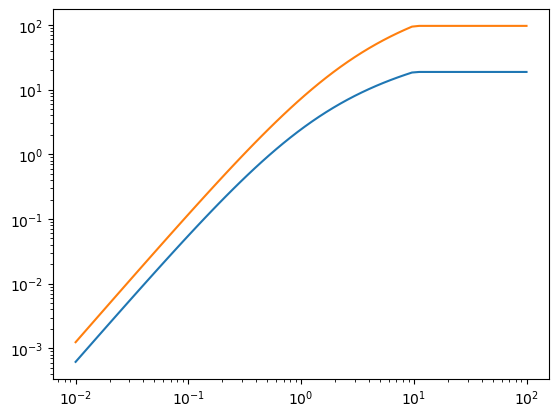

In [47]:
import matplotlib.pyplot as plt
nfw = NFWModel(
    rs_pc = 1,
    rhos_Msunpc3 = 1,
    r_t_pc = 1e1
)
print(nfw.params)
r = np.logspace(-2,2,64)
m = nfw.enclosure_mass(r)
plt.loglog(r,m)
nfw.update({'rs_pc': 2})
m = nfw.enclosure_mass(r)
plt.loglog(r,m)
plt.show()

In [37]:
d = dict({"b":2})
d.a = 1
d.b

2